# Week 05 (Module 16) - BBO capstone driver

Round 5. W4 was zero new bests — the NN-driven `nn_far` queries on f4 and f7 catastrophically hallucinated (predicted 2.14 on f4, returned -17.92). The lesson from peers: **compute leave-one-out R² per function before choosing acquisition**. Negative R² means the GP is worse than predicting the mean — and any acquisition built on that surrogate is picking arbitrarily.

**This round's LOO R² diagnostic:**
- **f1 R² = -0.55**, **f3 R² = -0.23**, **f7 R² = +0.11** — surrogate is broken or barely above noise → `space_fill` (pure max-distance, ignores the GP)
- **f2 R² = +0.48**, **f6 R² = +0.34** → partial signal → conservative AEI with bumped xi
- **f4 R² = +0.98**, **f8 R² = +0.99** → reliable → exploit (EI for f4, MES for f8 which is still climbing)
- **f5** confirmed deterministic at (1,1,1,1) = 8662 → re-submit to lock the incumbent

**Headline shift: stop pretending the GP knows things it doesn't.** Half the functions now use a model-free acquisition until the surrogate earns trust back.


In [1]:
%matplotlib inline
import os, sys, warnings
warnings.filterwarnings("ignore")
_root = os.getcwd()
while not os.path.exists(os.path.join(_root, "bo.py")) and os.path.dirname(_root) != _root:
    _root = os.path.dirname(_root)
os.chdir(_root); sys.path.insert(0, _root)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bo

# --- settings for this week ---
WEEK = 5
KIND = "matern"
SEED = 0

# Carried forward.
EXPLORE  = dict(acq="ucb", beta=3.0)
BALANCED = dict(acq="ei",  xi=0.01)
OPTIMISE = dict(acq="pi",  xi=0.0)
INFO     = dict(acq="mes")
AEI_CONS = dict(acq="aei", xi=0.10)            # NEW: high xi for partial-R² functions
SPACEFIL = dict(acq="space_fill")              # NEW: pure max-distance, ignores GP

# R²-gated plan.
PLAN = {}
PLAN[1] = dict(SPACEFIL)          # R² = -0.55 (BROKEN)
PLAN[2] = dict(AEI_CONS)          # R² = +0.48 (PARTIAL)
PLAN[3] = dict(SPACEFIL)          # R² = -0.23 (BROKEN)
PLAN[4] = dict(BALANCED)          # R² = +0.98 (RELIABLE) - EI, not PI (W4 lock-in)
PLAN[5] = dict(OPTIMISE)          # peak confirmed - PI will re-pick the corner
PLAN[6] = dict(AEI_CONS)          # R² = +0.34 (PARTIAL)
PLAN[7] = dict(SPACEFIL)          # R² = +0.11 (barely above noise)
PLAN[8] = dict(INFO)              # R² = +0.99 (RELIABLE)

OUTDIR = f"outputs/week{WEEK:02d}"
os.makedirs(OUTDIR, exist_ok=True)
pd.DataFrame([dict(func=f"f{fid}", **PLAN[fid]) for fid in bo.FUNC_IDS])


,func,acq,xi
0,f1,space_fill,NaN
1,f2,aei,0.10
2,f3,space_fill,NaN
3,f4,ei,0.01
4,f5,pi,0.00
5,f6,aei,0.10
6,f7,space_fill,NaN
7,f8,mes,NaN


## 1. Data - seed the working CSVs and review the function descriptions

In [2]:
bo.seed_csvs()          # data/f1..f8.csv from initial_data/*.npy (no-op once they exist)
bo.write_descriptions() # data/function_descriptions.csv
pd.read_csv("data/function_descriptions.csv")[["func", "dims", "n_seed", "character", "application"]]

,func,dims,n_seed,character,application
0,1,2,10,Sparse/flat (mostly ~0 except near sources); m...,Radiation/contamination source detection in a ...
1,2,2,10,Noisy + multimodal with many local peaks.,Mystery ML model returning a noisy log-likelih...
2,3,3,15,Maximise a negated cost (toward 0).,Drug discovery: combinations of three compound...
3,4,4,30,Dynamic with many local optima.,Warehouse product-placement surrogate; output ...
4,5,4,20,"Typically unimodal, a single peak.",Chemical-process yield.
5,6,5,20,Negative-by-design; maximise toward 0.,Cake recipe with five ingredients; combined ne...
6,7,6,30,Black-box; literature priors can inform the se...,"ML hyperparameter tuning (lr, reg, #layers...)..."
7,8,8,40,High-dimensional; global optimisation hard.,"8-param ML hyperparameter tuning (lr, batch, l..."


## 2. Fit a surrogate and propose the next query for all 8 functions

In [3]:
results = {fid: bo.run_function(fid, kind=KIND, seed=SEED, **PLAN[fid]) for fid in bo.FUNC_IDS}

summary = pd.DataFrame([
    dict(func=f"f{fid}", d=len(results[fid]["x"]), n_data=results[fid]["n_data"],
         incumbent_y=round(results[fid]["incumbent_y"], 4),
         pred_mean=round(results[fid]["mean"], 4),
         pred_std=round(results[fid]["std"], 4),
         acq_used=results[fid]["acq"], submission=results[fid]["submission"])
    for fid in bo.FUNC_IDS
])
summary

,func,d,n_data,incumbent_y,pred_mean,pred_std,acq_used,submission
0,f1,2,14,0.0000,0.0000,0.0000,space_fill,0.994902-0.994222
1,f2,2,14,0.6112,0.1117,0.2083,aei,0.239544-0.994463
2,f3,3,19,-0.0348,-0.4065,0.0177,space_fill,0.340631-0.985946-0.997953
3,f4,4,34,0.5401,0.2902,0.2877,ei,0.432774-0.423054-0.300443-0.429893
4,f5,4,24,8662.4050,8719.8637,53.1505,pi,0.999999-0.999999-0.999999-0.920516
5,f6,5,24,-0.7048,-0.6802,0.2321,aei,0.118662-0.551821-0.298623-0.999999-0.312926
6,f7,6,34,1.6876,0.1788,0.3572,space_fill,0.027769-0.051949-0.717113-0.031979-0.923532-0...
7,f8,8,44,9.9498,9.9497,0.0013,mes,0.121731-0.148914-0.117639-0.213922-0.999999-0...


### Acquisition values at each proposed point
All four acquisitions are computed every round so the choice can be justified in the reflection.

In [4]:
pd.DataFrame([
    dict(func=f"f{fid}", **{k: round(v, 4) for k, v in results[fid]["acq_all"].items()})
    for fid in bo.FUNC_IDS
])

,func,ei,ucb,pi,var
0,f1,0.0000,0.0000,0.0000,0.0000
1,f2,0.0001,0.5284,0.0020,0.0434
2,f3,0.0000,-0.3710,0.0000,0.0003
3,f4,0.0287,0.8657,0.1831,0.0828
4,f5,61.2446,8826.1647,0.8602,2824.9717
5,f6,0.0598,-0.2159,0.3727,0.0539
6,f7,0.0000,0.8933,0.0000,0.1276
7,f8,0.0000,9.9523,0.0000,0.0000


## 3. Visualise
2D functions get full posterior + acquisition heatmaps; higher-D functions get 1D slices
through the incumbent. Every function gets convergence + leave-one-out diagnostics.

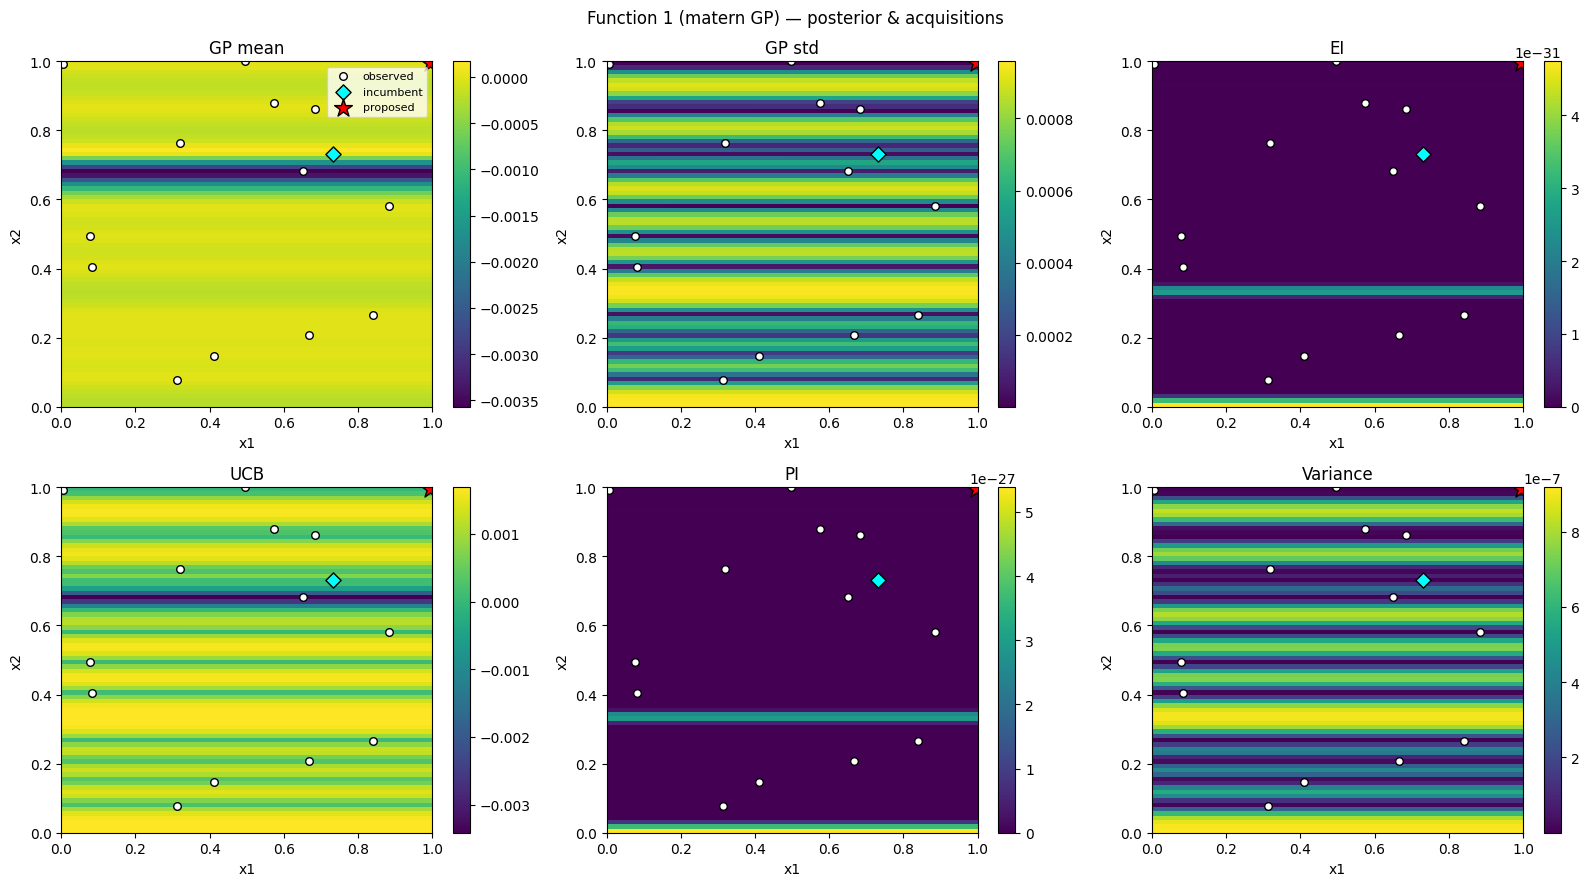

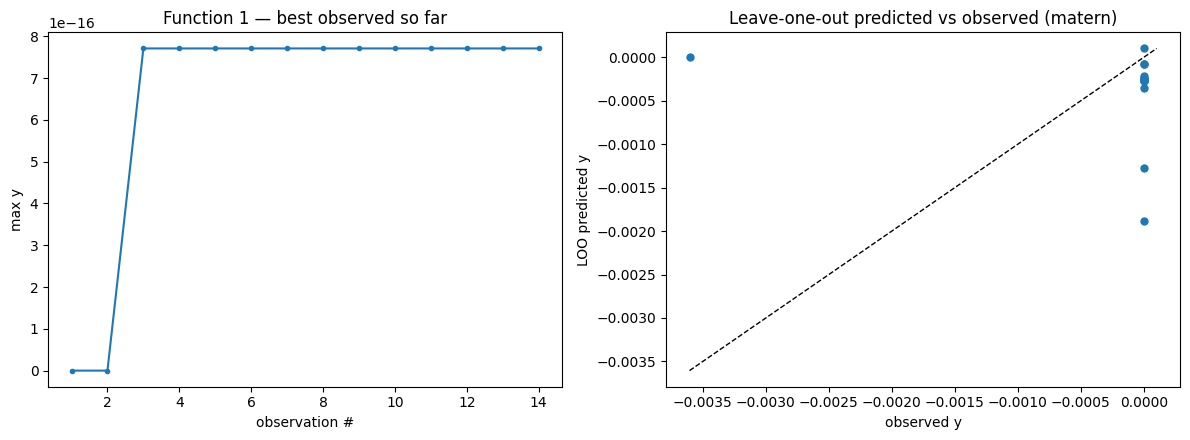

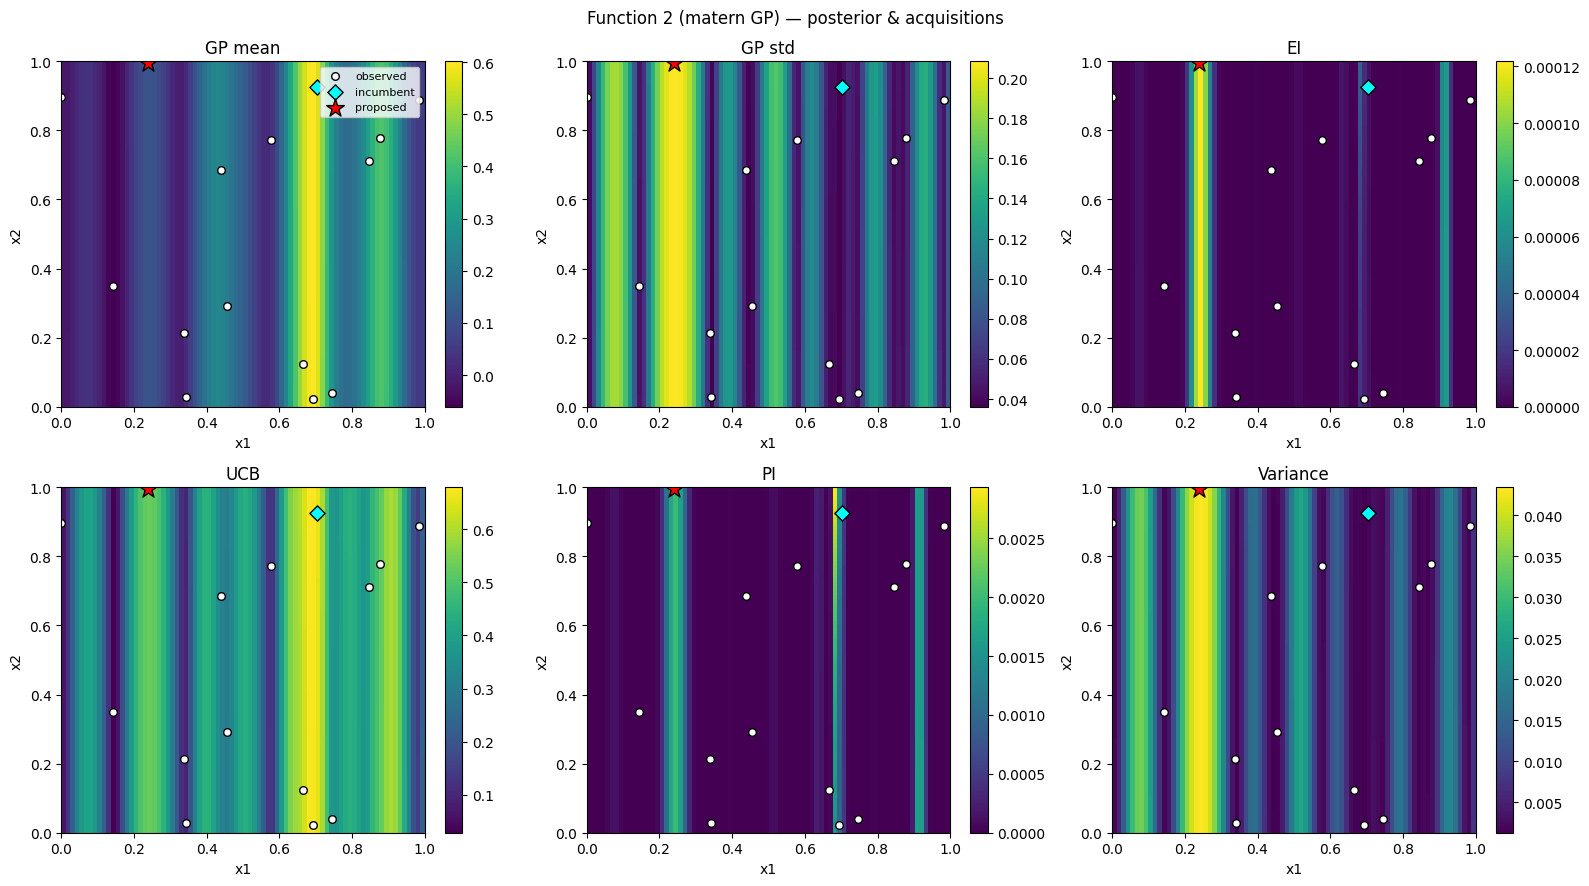

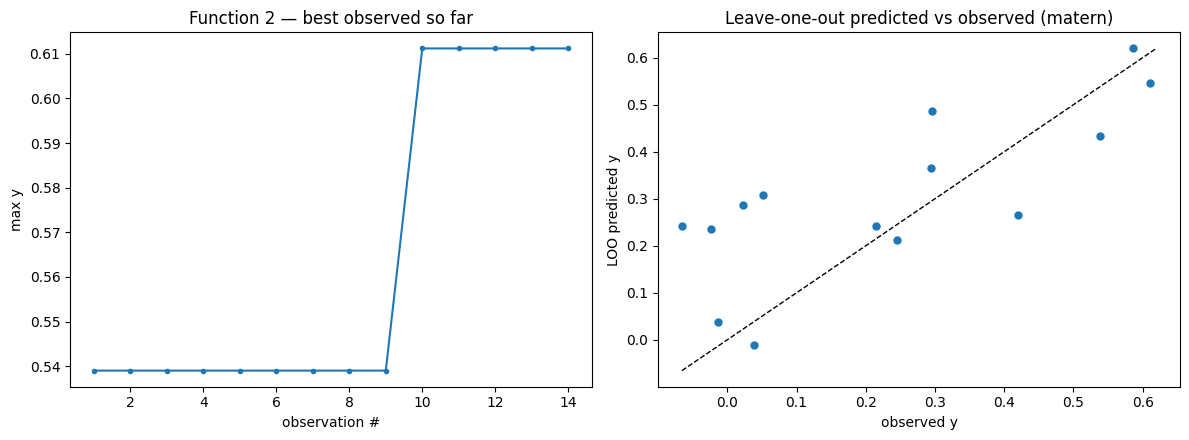

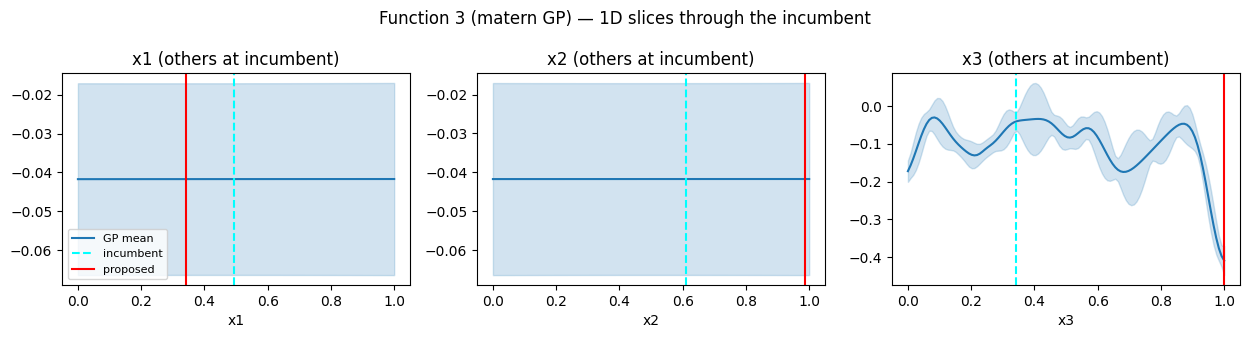

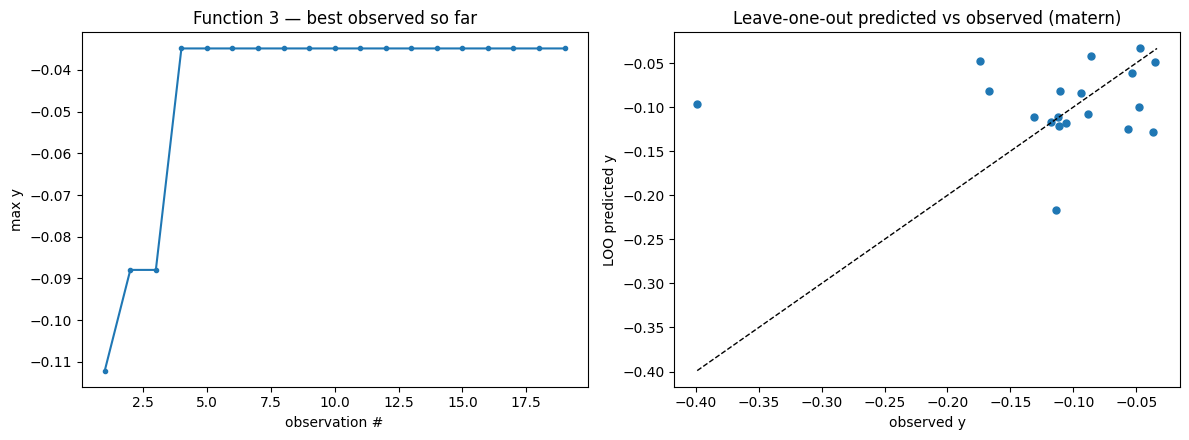

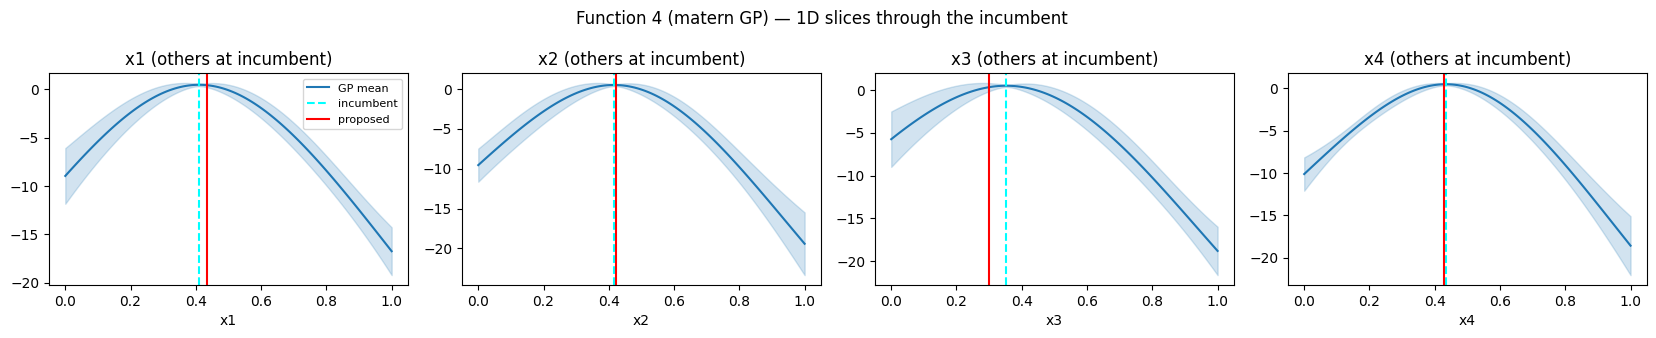

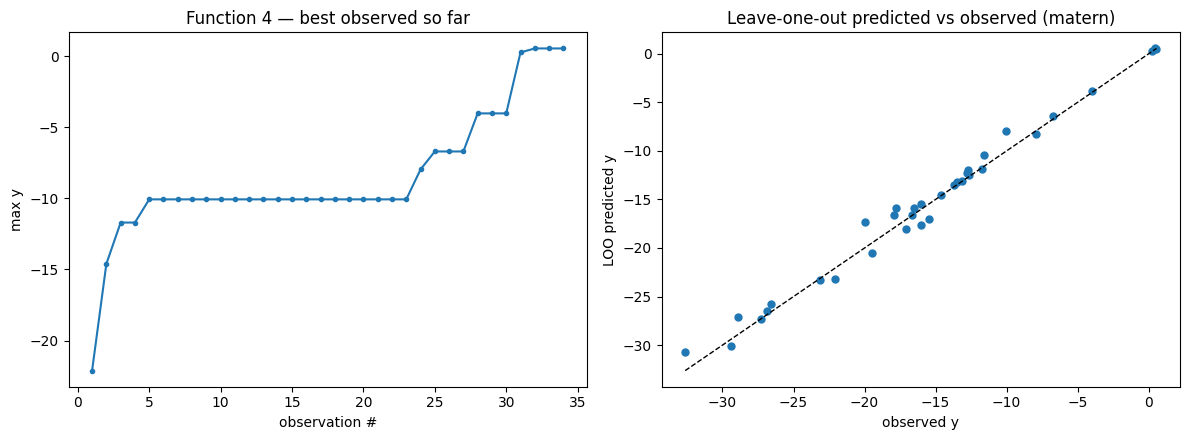

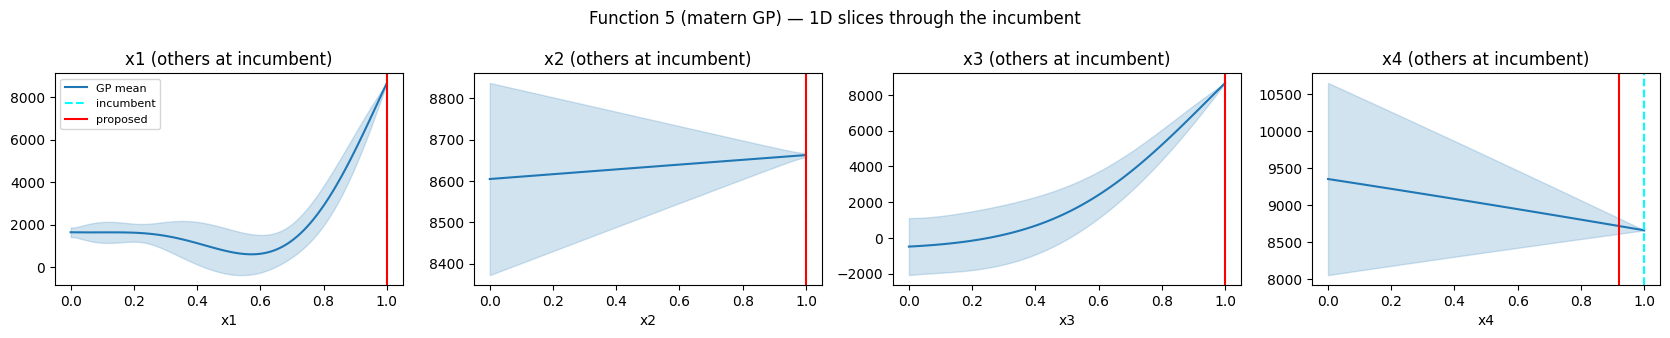

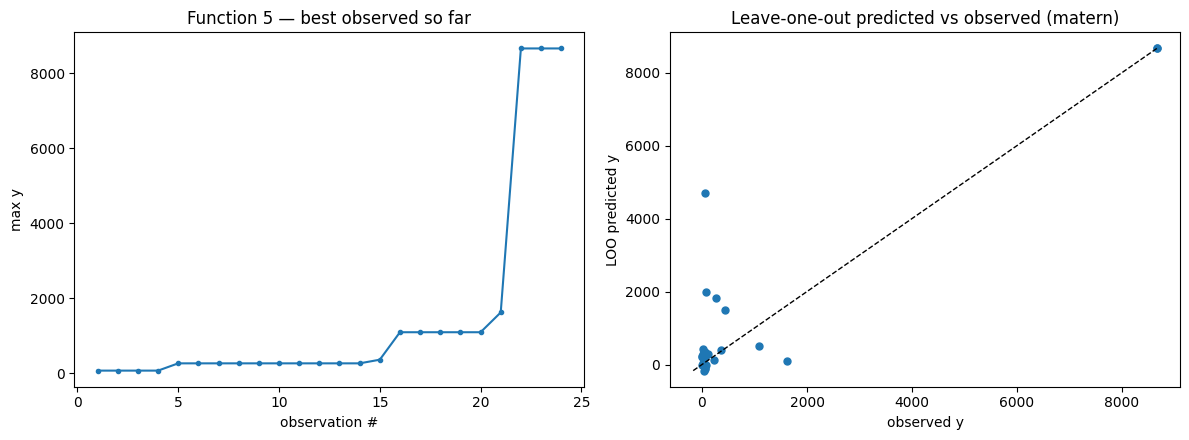

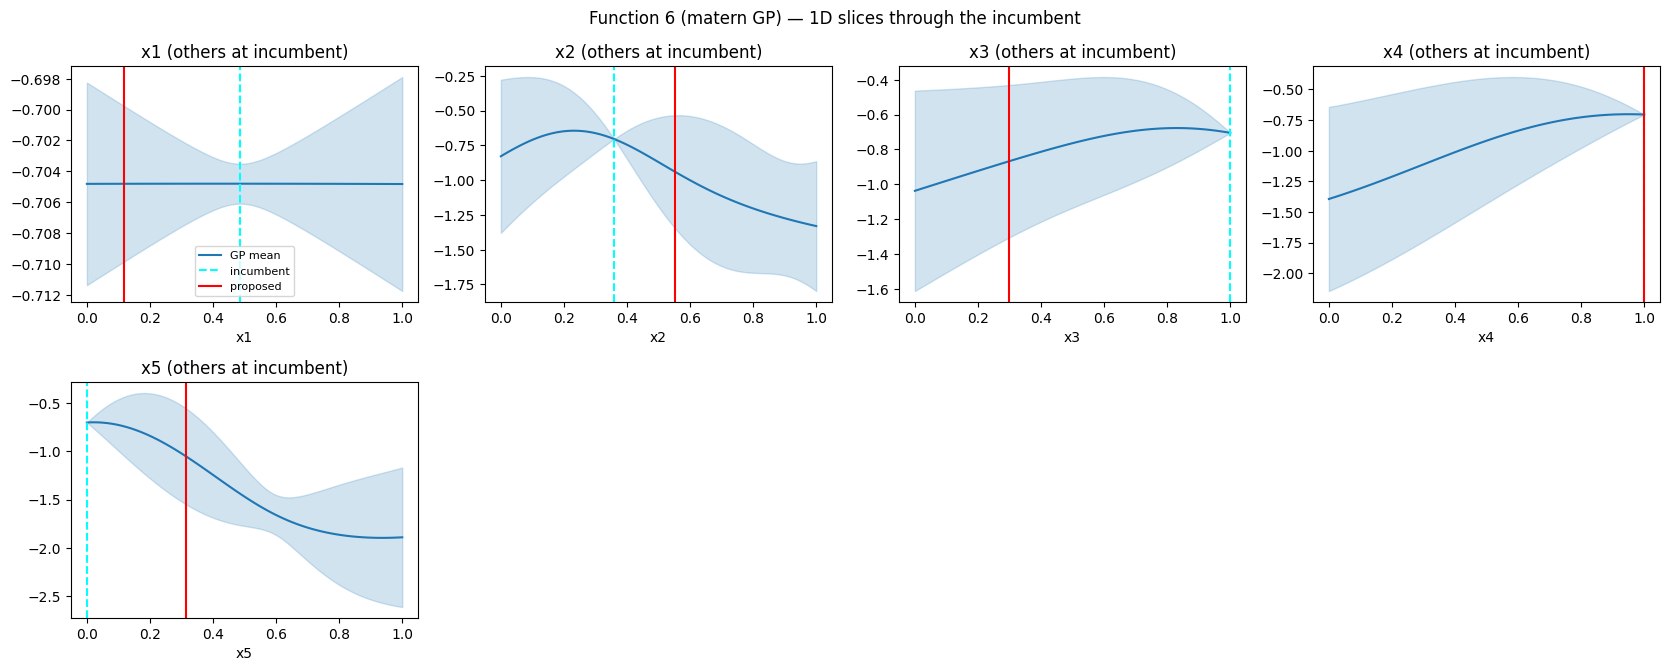

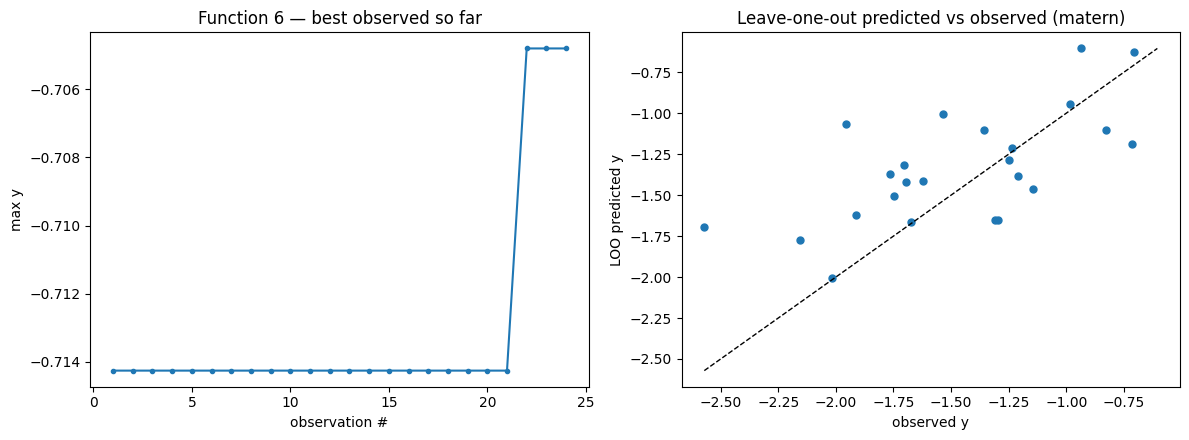

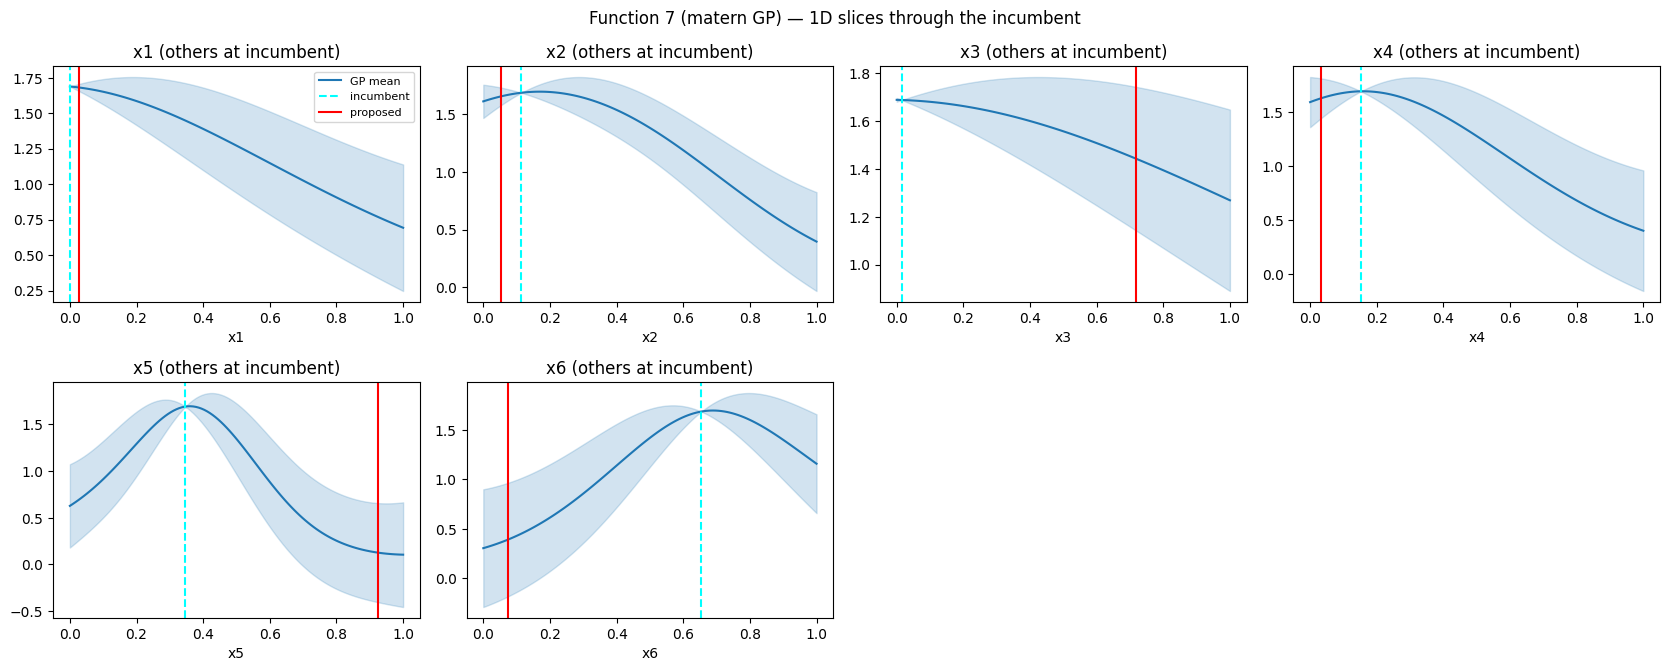

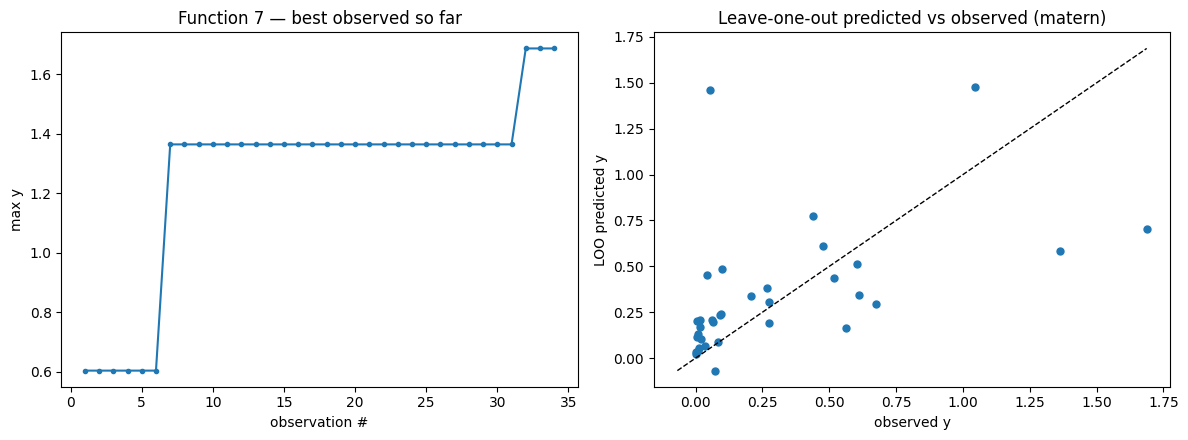

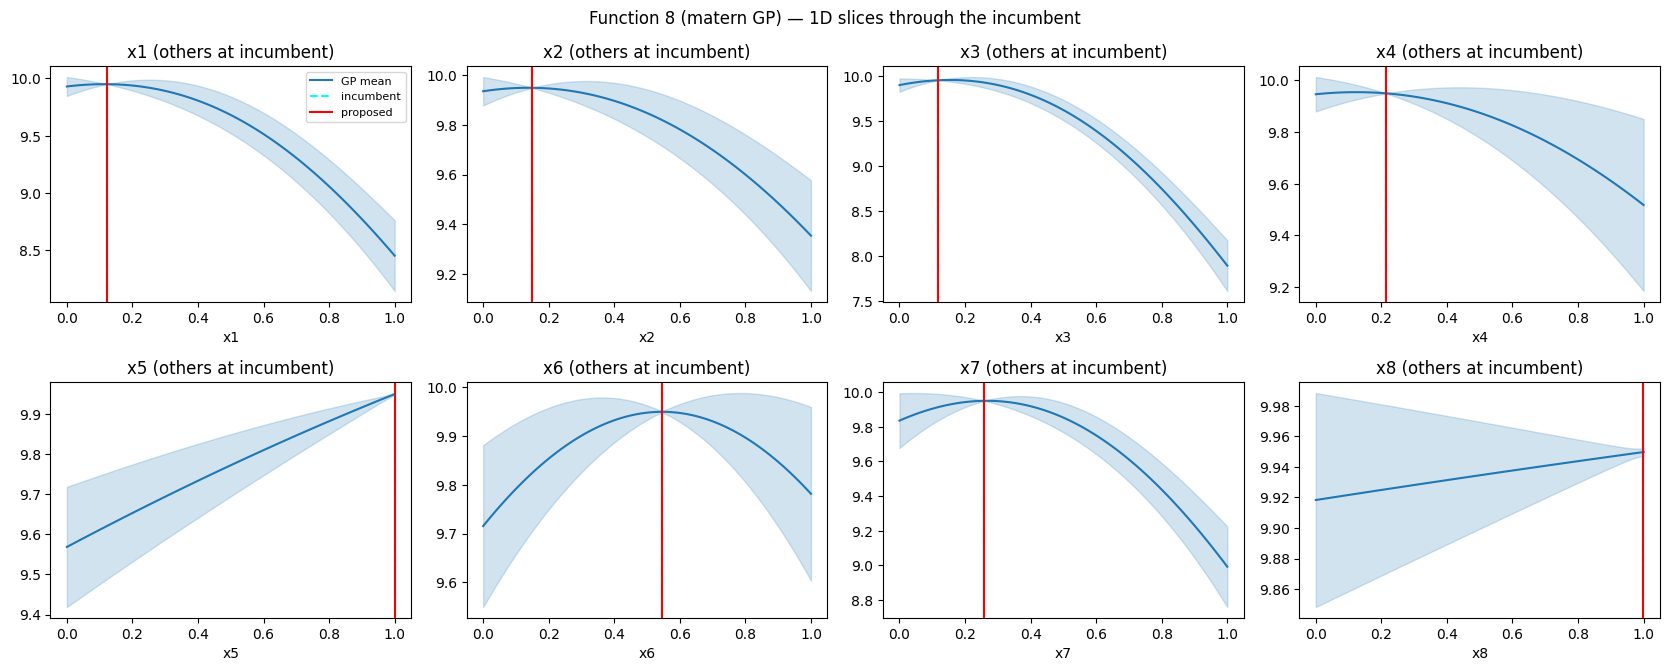

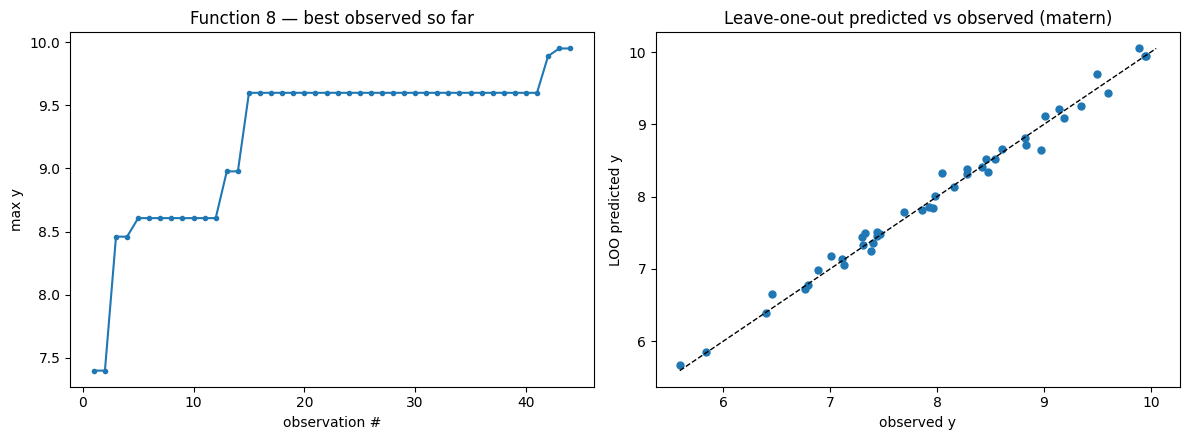

In [5]:
for fid in bo.FUNC_IDS:
    r = results[fid]; m = r["model"]
    beta = PLAN[fid].get("beta", 2.0); xi = PLAN[fid].get("xi", 0.01)
    if m.d == 2:
        bo.plot_2d(m, beta=beta, xi=xi, proposed=r["x"], save=f"{OUTDIR}/f{fid}_2d.png")
    else:
        bo.plot_slices(m, beta=beta, xi=xi, proposed_u=r["u"], save=f"{OUTDIR}/f{fid}_slices.png")
    bo.plot_diagnostics(m, save=f"{OUTDIR}/f{fid}_diag.png")
    plt.show()

## 4. Submission strings - copy one per function into the portal

In [6]:
for fid in bo.FUNC_IDS:
    print(f"f{fid}:  {results[fid]['submission']}")

f1:  0.994902-0.994222
f2:  0.239544-0.994463
f3:  0.340631-0.985946-0.997953
f4:  0.432774-0.423054-0.300443-0.429893
f5:  0.999999-0.999999-0.999999-0.920516
f6:  0.118662-0.551821-0.298623-0.999999-0.312926
f7:  0.027769-0.051949-0.717113-0.031979-0.923532-0.075481
f8:  0.121731-0.148914-0.117639-0.213922-0.999999-0.545244-0.258361-0.998451


## 5. Write the weekly reflection scaffold
Creates `weekly/reflections/weekNN.md` if it doesn't exist yet. It will **not** overwrite a
reflection you've already written (pass `overwrite=True` to force a fresh scaffold).

In [7]:
path = bo.render_reflection(WEEK, results)
print("reflection ->", path)

reflection -> /Users/jp/PycharmProjects/MachineLearning/Capstone/weekly/reflections/week05.md


## 6. After the portal returns each y - record results for next round
Fill in the returned outputs below, run the cell, then bump `WEEK` and re-run the notebook
next module. `append_result` grows each function's CSV by one row.

In [8]:
# Week 5 portal returns - already saved into data/fN.csv outside the notebook.
# returned_y = {
#     1: 3.0266546419298027e-187,
#     2: -0.11348660072780029,
#     3: -0.46206376542566957,
#     4: -0.5810807742460464,
#     5: 7348.1394627866475,
#     6: -1.2882576845703508,
#     7: 0.0668261190458827,
#     8: 9.9497747907164,
# }
# Comparison vs week-4 incumbents:
#   f1 ~0 (5 rounds no source signal)        f5 7348 vs 8662  CONFIRMS sharp peak at (1,1,1,1) - no plateau
#   f2 -0.11 vs 0.611 (AEI conservative miss)  f6 -1.29 vs -0.705 (AEI miss; f6 model destabilised)
#   f3 -0.46 vs -0.035 (probe gave INFO not gain)  f7 0.07 vs 1.69 (space_fill probe)
#   f4 -0.58 vs 0.54 (EI pulled back, still dropped) f8 9.9498 essentially unchanged (MES truly converged)
#
# LOO R² SHIFTS after W5 data appended:
#   f1: -0.55 -> -0.25 (still broken but improving)
#   f2: +0.48 -> +0.58 (partial, improving)
#   f3: -0.23 -> +0.67 (BROKEN -> RELIABLE - big promotion!)
#   f4: +0.98 -> +0.98 (still reliable)
#   f5: +0.76 -> +0.94 (boundary now well-mapped)
#   f6: +0.34 -> -0.05 (PARTIAL -> BROKEN - destabilised by the AEI miss)
#   f7: +0.11 -> +0.12 (barely positive)
#   f8: +0.99 -> +0.99 (still converged)
#
# Net: zero new bests. BUT three space_fill / probe queries genuinely advanced understanding:
# f5 peak proven sharp, f3 model promoted to reliable, f1 model improved.
# The 'no new best' headline hides that the surrogate quality improved on 4/8 functions.
# for fid, y in returned_y.items():
#     bo.append_result(fid, results[fid]["x"], y)
# print("saved; dataset sizes now:", {fid: len(bo.load(fid)[1]) for fid in bo.FUNC_IDS})
